## Chapter 1 of *Linear Models with R* (3e, 2025)

In [1]:
from hea.R import *
from hea.plot import *
from hea import data, col, lm

### 1.2

In [2]:
pima = data("pima")
head(pima)

pregnant,glucose,diastolic,triceps,insulin,bmi,diabetes,age,test
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
5,116,74,0,0,25.6,0.201,30,0


In [3]:
summary(pima)

   pregnant        glucose       diastolic        triceps        insulin
Min.   : 0.000  Min.   :  0.0  Min.   :  0.00  Min.   : 0.00  Min.   :  0.00
1st Qu.: 1.000  1st Qu.: 99.0  1st Qu.: 62.00  1st Qu.: 0.00  1st Qu.:  0.00
Median : 3.000  Median :117.0  Median : 72.00  Median :23.00  Median : 30.50
Mean   : 3.845  Mean   :120.9  Mean   : 69.11  Mean   :20.54  Mean   : 79.80
3rd Qu.: 6.000  3rd Qu.:140.2  3rd Qu.: 80.00  3rd Qu.:32.00  3rd Qu.:127.25
Max.   :17.000  Max.   :199.0  Max.   :122.00  Max.   :99.00  Max.   :846.00

     bmi          diabetes           age            test
Min.   : 0.00  Min.   :0.07800  Min.   :21.00  Min.   :0.0000
1st Qu.:27.30  1st Qu.:0.24375  1st Qu.:24.00  1st Qu.:0.0000
Median :32.00  Median :0.37250  Median :29.00  Median :0.0000
Mean   :31.99  Mean   :0.47188  Mean   :33.24  Mean   :0.3490
3rd Qu.:36.60  3rd Qu.:0.62625  3rd Qu.:41.00  3rd Qu.:1.0000
Max.   :67.10  Max.   :2.42000  Max.   :81.00  Max.   :1.0000

In [4]:
# we will just default to the tidyverse way
pima = pima.mutate(
    col("diastolic", "glucose", "triceps", "insulin", "bmi").replace(0, None),
    test = factor(col("test"), labels={0: "negative", 1: "positive"})
)

summary(pima)

# the R-base way
# pima$diastolic[pima$diastolic == 0] = NA
# pima$glucose[pima$glucose == 0] = NA
# pima$triceps[pima$triceps == 0] = NA
# pima$insulin[pima$insulin == 0] = NA
# pima$bmi[pima$bmi == 0] = NA
# pima$test = factor(pima$test)
# levels(pima$test) = c("negative","positive")
# summary(pima$test)

   pregnant        glucose       diastolic        triceps        insulin
Min.   : 0.000  Min.   : 44.0  Min.   : 24.00  Min.   : 7.00  Min.   : 14.00
1st Qu.: 1.000  1st Qu.: 99.0  1st Qu.: 64.00  1st Qu.:22.00  1st Qu.: 76.25
Median : 3.000  Median :117.0  Median : 72.00  Median :29.00  Median :125.00
Mean   : 3.845  Mean   :121.7  Mean   : 72.41  Mean   :29.15  Mean   :155.55
3rd Qu.: 6.000  3rd Qu.:141.0  3rd Qu.: 80.00  3rd Qu.:36.00  3rd Qu.:190.00
Max.   :17.000  Max.   :199.0  Max.   :122.00  Max.   :99.00  Max.   :846.00
                NA's   :    5  NA's   :    35  NA's   :  227  NA's   :   374

     bmi          diabetes           age           test
Min.   :18.20  Min.   :0.07800  Min.   :21.00  negative:500
1st Qu.:27.50  1st Qu.:0.24375  1st Qu.:24.00  positive:268
Median :32.30  Median :0.37250  Median :29.00
Mean   :32.46  Mean   :0.47188  Mean   :33.24
3rd Qu.:36.60  3rd Qu.:0.62625  3rd Qu.:41.00
Max.   :67.10  Max.   :2.42000  Max.   :81.00
NA's   :   11

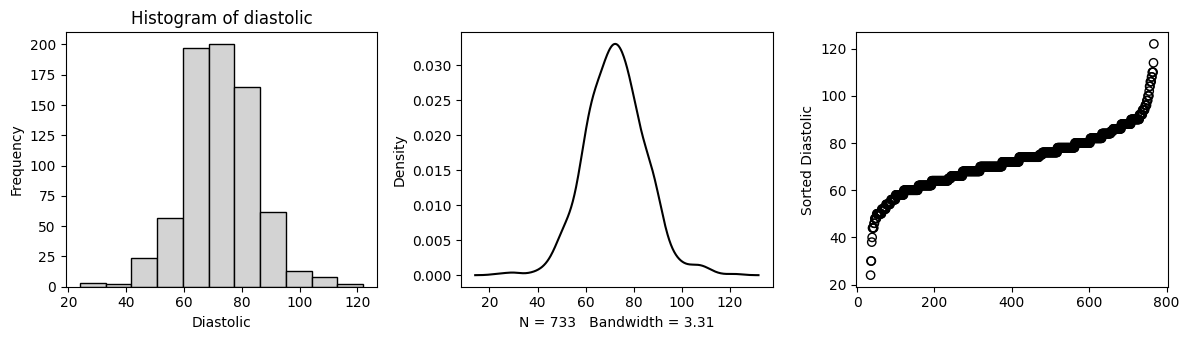

In [5]:
with par(mfrow=(1, 3)):
    hist(pima["diastolic"], xlab="Diastolic")
    plot(density(pima["diastolic"]), main="")
    plot(sort(pima["diastolic"]), ylab="Sorted Diastolic")

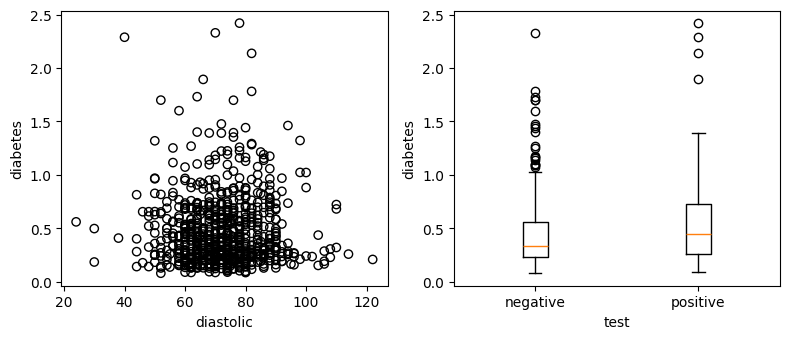

In [6]:
with par(mfrow=(1, 2)):
    plot("diabetes ~ diastolic", pima)
    plot("diabetes ~ test", pima)


/Users/ziweih/Works/hea/hea/ggplot/_block.py:1358: UserWarning: Removed 35 rows containing missing values (`geom_bar()`).
  cells[r][c] = (child, compute_block(child, collect_state=collect_state))
/Users/ziweih/Works/hea/hea/ggplot/_block.py:1358: UserWarning: Removed 35 rows containing missing values (`geom_density()`).
  cells[r][c] = (child, compute_block(child, collect_state=collect_state))
/Users/ziweih/Works/hea/hea/ggplot/_block.py:1358: UserWarning: Removed 35 rows containing missing values (`geom_point()`).
  cells[r][c] = (child, compute_block(child, collect_state=collect_state))


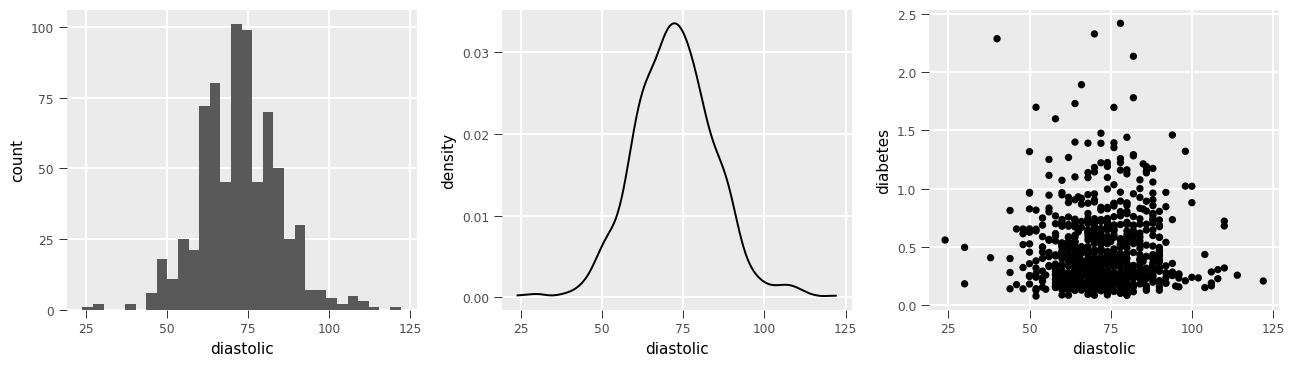

<Figure size 1273.88x351 with 0 Axes>

In [7]:
p1 = pima.ggplot(x="diastolic").geom_histogram()
p2 = pima.ggplot(x="diastolic").geom_density()
p3 = pima.ggplot(x="diastolic", y="diabetes").geom_point()

p1 | p2 | p3

/Users/ziweih/Works/hea/hea/ggplot/_block.py:1358: UserWarning: Removed 35 rows containing missing values (`geom_point()`).
  cells[r][c] = (child, compute_block(child, collect_state=collect_state))


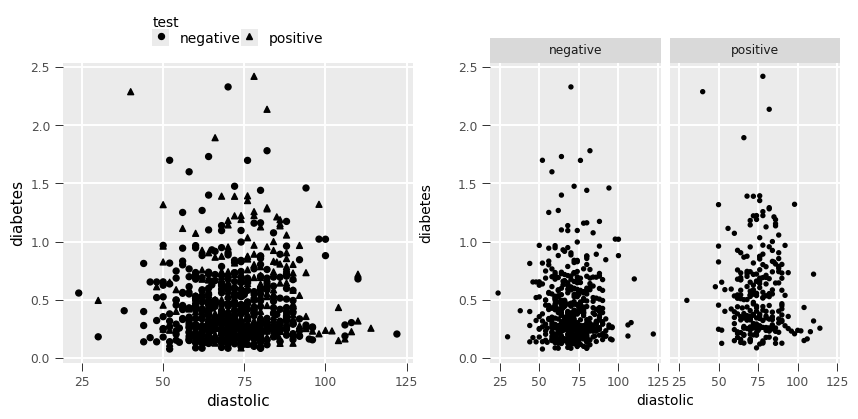

<Figure size 835x395.7 with 0 Axes>

In [8]:
from hea.ggplot import theme
p1 = (
    pima.ggplot(x="diastolic", y="diabetes", shape="test")
        .geom_point()
         & theme(legend_position="top", legend_direction="horizontal")
)
p2 = (
    pima.ggplot(x="diastolic", y="diabetes")
        .geom_point(size=1)
        .facet_grid("~ test")
)

(p1 + p2)

### 1.4

In [9]:
manilius = data("manilius")
manilius.head()

arc,sinang,cosang,group
f64,f64,f64,i64
13.166667,0.8836,-0.4682,1
13.133333,0.9996,-0.0282,1
13.2,0.9899,0.1421,1
14.25,0.2221,0.975,3
14.7,0.0006,1.0,3


In [10]:
manilius.group_by("group").summarize(col("arc", "sinang", "cosang").sum())

group,arc,sinang,cosang
i64,f64,f64,f64
1,118.133333,8.4987,-0.7932
3,127.533333,2.9777,7.9649
2,140.283333,-6.1404,1.7443


In [11]:
m1 = lm('arc ~ sinang + cosang', manilius)
m1.coef

(Intercept),sinang,cosang
f64,f64,f64
14.561624,-1.504581,0.091365


<Axes: xlabel='midparentHeight', ylabel='childHeight'>

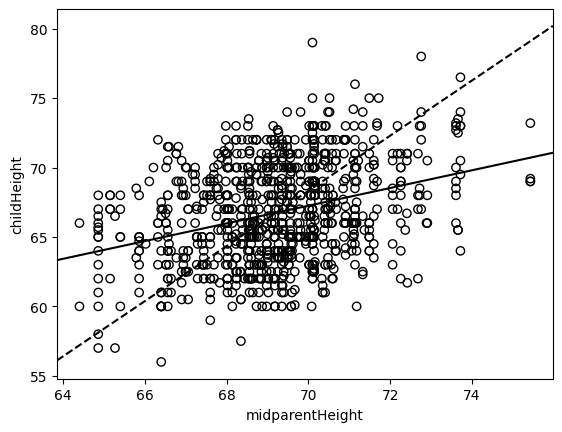

In [12]:
GaltonFamilies = data("GaltonFamilies")

beta1 = GaltonFamilies["childHeight"].std() / GaltonFamilies["midparentHeight"].std()
alpha1 = GaltonFamilies["childHeight"].mean() - beta1 * GaltonFamilies["midparentHeight"].mean()

m2 = lm('childHeight ~ midparentHeight', GaltonFamilies)

ax = plot('childHeight ~ midparentHeight', GaltonFamilies)
abline(alpha1, beta1, lty=2, ax=ax)
abline(m2, ax=ax)